# TP2 — Probabilidade e Estatística Descritiva

**CloudDesk — Base de Tickets de Suporte**  
**Aluno: Guilherme Reis de Jesus Santos**  
**Curso: Ciência da Computação — Instituto Infnet**

## Preparação — carregamento e consolidação do dataset

Reutilizando o pipeline do TP1: leitura das três fontes, correção de tipos, remoção de duplicatas, imputação de nulos e merge.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- leitura ---
df_tickets = pd.read_csv("tickets_suporte.csv")
df_planos  = pd.read_excel("planos_clientes.xlsx")
df_chatbot = pd.read_json("chatbot_triagem.json")

# --- correções do TP1 ---
df_tickets["tempo_resposta_horas"] = (
    df_tickets["tempo_resposta_horas"]
    .astype(str).str.replace(",", ".", regex=False)
    .replace("", float("nan")).replace("nan", float("nan")).astype(float)
)
df_tickets = df_tickets.drop_duplicates(subset=["ticket_id"], keep="first")
df_tickets["data_abertura"] = pd.to_datetime(df_tickets["data_abertura"])
df_tickets["tempo_resposta_horas"] = df_tickets.groupby("categoria")["tempo_resposta_horas"].transform(
    lambda x: x.fillna(x.median())
)
for col in ["canal", "categoria", "prioridade"]:
    df_tickets[col] = df_tickets[col].astype("category")

# --- merge ---
df = pd.merge(df_tickets, df_planos, on="cliente_id", how="left")
df = pd.merge(df, df_chatbot, on="ticket_id", how="left")

print(f"Dataset consolidado: {df.shape}")
print(df.dtypes)

Dataset consolidado: (4000, 13)
ticket_id                        object
cliente_id                       object
data_abertura            datetime64[ns]
canal                          category
categoria                      category
prioridade                     category
tempo_resposta_horas            float64
tempo_resolucao_horas           float64
satisfacao_cliente              float64
valor_plano                       int64
segmento                         object
intencao_triagem                 object
confianca_bot                   float64
dtype: object


---

## Exercício 1 — Estimativas de probabilidade

In [6]:

p_alta = (df["prioridade"] == "alta").mean()
print(f"P(alta) = {p_alta:.4f}  ({p_alta*100:.2f}%)")
print(f"  Contagem: {(df['prioridade'] == 'alta').sum()} tickets de {len(df)} total")

df["semana_ano"] = df["data_abertura"].dt.to_period("W")
por_semana = (
    df.groupby(["cliente_id", "semana_ano"])["ticket_id"]
    .count()
    .reset_index(name="n_tickets")
)
p_mais_de_um = (por_semana["n_tickets"] > 1).mean()
print(f"\nP(>1 ticket na semana) = {p_mais_de_um:.4f}  ({p_mais_de_um*100:.2f}%)")
print(f"  Pares (cliente, semana) com >1 ticket: {(por_semana['n_tickets'] > 1).sum()} de {len(por_semana)}")

p_chat        = (df["canal"] == "chat").mean()
p_alta_e_chat = ((df["prioridade"] == "alta") & (df["canal"] == "chat")).mean()
p_alta_ou_chat = p_alta + p_chat - p_alta_e_chat  

print(f"\nP(chat)              = {p_chat:.4f}")
print(f"P(alta ∩ chat)       = {p_alta_e_chat:.4f}")
print(f"P(alta ∪ chat)       = {p_alta:.4f} + {p_chat:.4f} - {p_alta_e_chat:.4f} = {p_alta_ou_chat:.4f}  ({p_alta_ou_chat*100:.2f}%)")

P(alta) = 0.2540  (25.40%)
  Contagem: 1016 tickets de 4000 total

P(>1 ticket na semana) = 0.3701  (37.01%)
  Pares (cliente, semana) com >1 ticket: 993 de 2683

P(chat)              = 0.3493
P(alta ∩ chat)       = 0.0872
P(alta ∪ chat)       = 0.2540 + 0.3493 - 0.0872 = 0.5160  (51.60%)


### Interpretação — Exercício 1

**1.1 — P(alta) ≈ 25,4%**
Aproximadamente 1 em cada 4 tickets é de prioridade alta. O resultado está alinhado com a proporção esperada de geração dos dados (25%).

**1.2 — P(>1 ticket na mesma semana) ≈ 37%**
Em 37% das combinações (cliente + semana), o cliente abriu mais de um ticket na mesma semana. Isso indica que problemas tendem a se concentrar em períodos curtos.

**1.3 — P(alta ∪ chat) ≈ 51,6%**
Usamos a lei da adição para não contar duas vezes os tickets que são alta prioridade e canal chat ao mesmo tempo. Sem esse ajuste, a probabilidade seria superestimada em cerca de 9 pontos percentuais.

---

## Exercício 2 — Variáveis contínuas vs. discretas

In [7]:
print("=== tempo_resposta_horas ===")
print(df["tempo_resposta_horas"].describe())
print(f"Valores únicos (amostra): {df['tempo_resposta_horas'].nunique()} de {len(df)}")

print("\n=== satisfacao_cliente ===")
print(df["satisfacao_cliente"].value_counts().sort_index())

print("\n=== categoria ===")
print(df["categoria"].value_counts())

=== tempo_resposta_horas ===
count    4000.000000
mean        3.811945
std         2.829681
min         0.120000
25%         1.860000
50%         3.130000
75%         4.970000
max        25.880000
Name: tempo_resposta_horas, dtype: float64
Valores únicos (amostra): 1008 de 4000

=== satisfacao_cliente ===
satisfacao_cliente
1.0       7
2.0      58
3.0     648
4.0    1717
5.0    1170
Name: count, dtype: int64

=== categoria ===
categoria
bug              1387
duvida_de_uso    1192
cobranca         1028
elogio            393
Name: count, dtype: int64


### Classificação das variáveis — Exercício 2

**`tempo_resposta_horas` → variável contínua**
Pode assumir qualquer valor real positivo (ex.: 2,7h, 15,3h). Não há saltos naturais entre os valores. A distribuição mais adequada é a Gamma, pois os valores são sempre positivos e a distribuição é assimétrica à direita.

**`satisfacao_cliente` → variável discreta ordinal**
Assume apenas os inteiros de 1 a 5. Não faz sentido falar em nota 3,7. A escala tem ordem (5 > 4 > ... > 1), mas os intervalos entre notas não são necessariamente iguais.

**`categoria` → variável discreta nominal**
Assume um conjunto fixo de valores sem ordem: *bug*, *duvida_de_uso*, *cobranca*, *elogio*. A distribuição adequada é a categórica, com probabilidade proporcional à frequência de cada categoria.

---

## Exercício 3 — CDF empírica de `tempo_resposta_horas`

Observações usadas: 4000
F(10h)  = P(tempo ≤ 10h) = 0.9590  (95.90%)
1−F(10h) = P(tempo > 10h) = 0.0410  (4.10%)


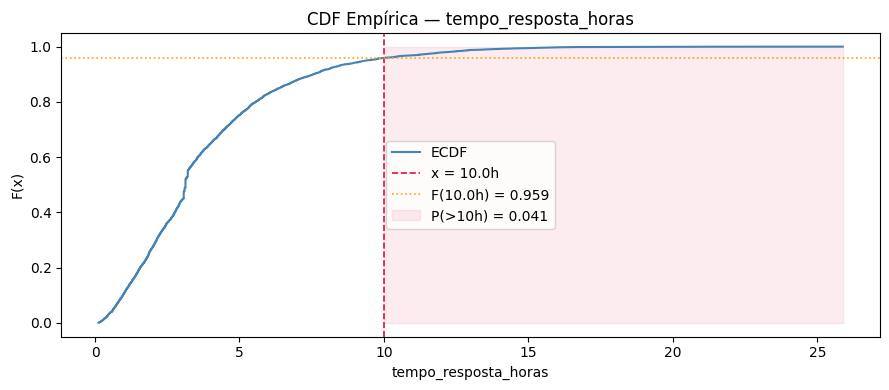

In [8]:
serie = df["tempo_resposta_horas"].dropna().sort_values().reset_index(drop=True)
n_obs = len(serie)

cdf_valores = np.arange(1, n_obs + 1) / n_obs

threshold = 10.0
idx = np.searchsorted(serie.values, threshold, side="right")
p_ate_10  = idx / n_obs          
p_acima_10 = 1 - p_ate_10        

print(f"Observações usadas: {n_obs}")
print(f"F(10h)  = P(tempo ≤ 10h) = {p_ate_10:.4f}  ({p_ate_10*100:.2f}%)")
print(f"1−F(10h) = P(tempo > 10h) = {p_acima_10:.4f}  ({p_acima_10*100:.2f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(serie, cdf_valores, lw=1.5, color="steelblue", label="ECDF")
ax.axvline(threshold, color="crimson", ls="--", lw=1.2, label=f"x = {threshold}h")
ax.axhline(p_ate_10,  color="orange",  ls=":",  lw=1.2, label=f"F({threshold}h) = {p_ate_10:.3f}")
ax.fill_betweenx([0, 1], threshold, serie.max(), alpha=0.08, color="crimson", label=f"P(>10h) = {p_acima_10:.3f}")
ax.set_xlabel("tempo_resposta_horas")
ax.set_ylabel("F(x)")
ax.set_title("CDF Empírica — tempo_resposta_horas")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretação — Exercício 3

A CDF empírica ordena todos os tickets pelo tempo de resposta e mostra, para cada valor, qual proporção de tickets ficou abaixo dele.

- **F(10h) ≈ 95,9%**: quase 96% dos tickets são respondidos em até 10 horas.
- **P(tempo > 10h) ≈ 4,1%**: apenas cerca de 4% dos tickets ultrapassam 10h.

Usar só a média (~3,8h) levaria à conclusão de que tudo está bem mas a CDF revela os casos extremos que podem gerar penalidades de SLA e insatisfação do cliente.

---

## Exercício 4 — Histograma e boxplot

C:\Users\gabib\AppData\Local\Temp\ipykernel_54456\3727891433.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


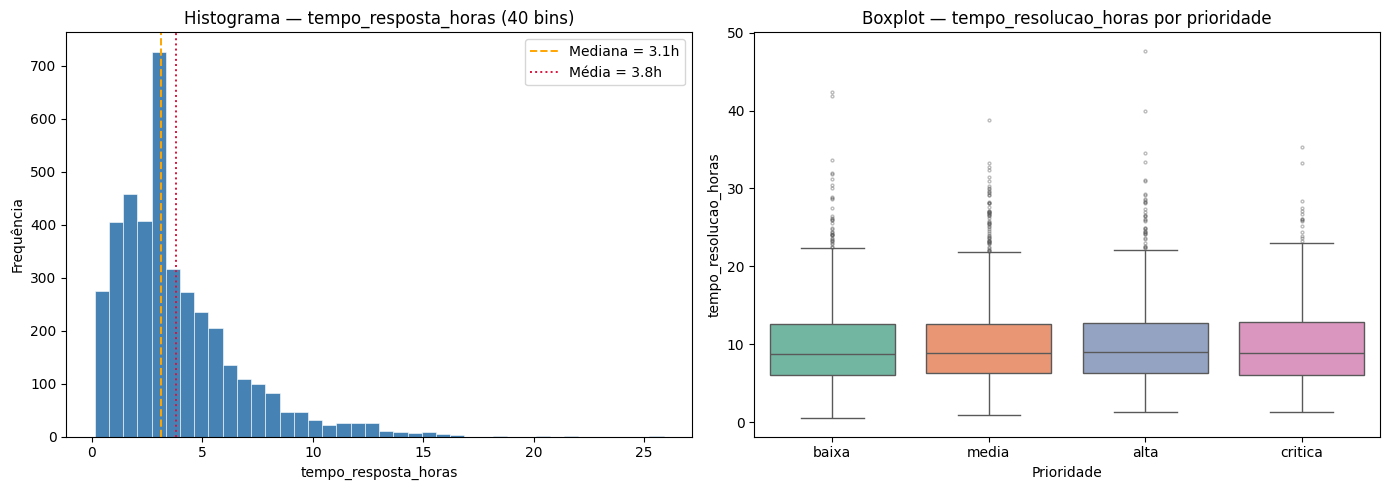

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["tempo_resposta_horas"].dropna(),
    bins=40,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4,
)
axes[0].set_xlabel("tempo_resposta_horas")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Histograma — tempo_resposta_horas (40 bins)")
axes[0].axvline(
    df["tempo_resposta_horas"].median(),
    color="orange", ls="--", lw=1.4, label=f"Mediana = {df['tempo_resposta_horas'].median():.1f}h"
)
axes[0].axvline(
    df["tempo_resposta_horas"].mean(),
    color="crimson", ls=":", lw=1.4, label=f"Média = {df['tempo_resposta_horas'].mean():.1f}h"
)
axes[0].legend()

ordem_prioridade = ["baixa", "media", "alta", "critica"]
sns.boxplot(
    data=df,
    x="prioridade",
    y="tempo_resolucao_horas",
    order=ordem_prioridade,
    palette="Set2",
    ax=axes[1],
    flierprops=dict(marker="o", markersize=2, alpha=0.4),
)
axes[1].set_title("Boxplot — tempo_resolucao_horas por prioridade")
axes[1].set_xlabel("Prioridade")
axes[1].set_ylabel("tempo_resolucao_horas")

plt.tight_layout()
plt.show()

### Observações — Exercício 4

**Histograma (`tempo_resposta_horas`):**
A distribuição é assimétrica à direita: a maioria dos tickets é respondida em menos de 6 horas, mas há uma cauda com casos chegando a 48h. A mediana (laranja) está abaixo da média (vermelho), confirmando a assimetria.

**Boxplot (`tempo_resolucao_horas` por prioridade):**
- **Baixa**: maior concentração de outliers tickets de baixa prioridade ficam parados sem urgência operacional.
- **Crítica**: menor dispersão, mas mediana mais alta resolvidos com urgência, porém são problemas mais complexos.
- **Média e alta**: perfis intermediários.

---

## Exercício 5 — Scatter plots

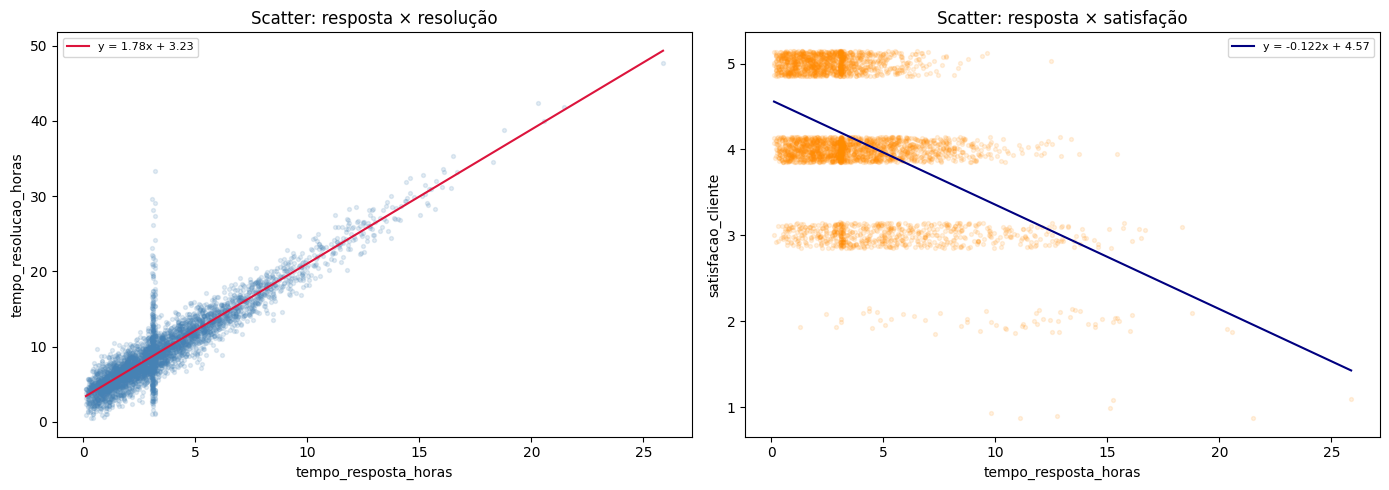

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    df["tempo_resposta_horas"],
    df["tempo_resolucao_horas"],
    alpha=0.15, s=8, color="steelblue"
)

mask = df[["tempo_resposta_horas", "tempo_resolucao_horas"]].notna().all(axis=1)
m, b = np.polyfit(df.loc[mask, "tempo_resposta_horas"], df.loc[mask, "tempo_resolucao_horas"], 1)
x_lin = np.linspace(df["tempo_resposta_horas"].min(), df["tempo_resposta_horas"].max(), 100)
axes[0].plot(x_lin, m * x_lin + b, color="crimson", lw=1.5, label=f"y = {m:.2f}x + {b:.2f}")
axes[0].set_xlabel("tempo_resposta_horas")
axes[0].set_ylabel("tempo_resolucao_horas")
axes[0].set_title("Scatter: resposta × resolução")
axes[0].legend(fontsize=8)

mask2 = df[["tempo_resposta_horas", "satisfacao_cliente"]].notna().all(axis=1)
axes[1].scatter(
    df.loc[mask2, "tempo_resposta_horas"],
    df.loc[mask2, "satisfacao_cliente"] + np.random.default_rng(7).uniform(-0.15, 0.15, mask2.sum()),
    alpha=0.12, s=8, color="darkorange"
)
m2, b2 = np.polyfit(df.loc[mask2, "tempo_resposta_horas"], df.loc[mask2, "satisfacao_cliente"], 1)
axes[1].plot(x_lin, m2 * x_lin + b2, color="navy", lw=1.5, label=f"y = {m2:.3f}x + {b2:.2f}")
axes[1].set_xlabel("tempo_resposta_horas")
axes[1].set_ylabel("satisfacao_cliente")
axes[1].set_title("Scatter: resposta × satisfação")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Interpretação — Exercício 5

**Scatter 1 — resposta × resolução:**
Associação linear positiva moderada a forte: tickets que demoram para ser respondidos também demoram mais para ser resolvidos. Isso faz sentido operacionalmente o atraso inicial se propaga para o fechamento.

**Scatter 2 — resposta × satisfação:**
Associação linear negativa fraca: há leve tendência de queda na satisfação quando o tempo de resposta aumenta, mas a dispersão é grande e a variável de satisfação só assume 5 valores inteiros, o que dificulta visualizar padrões mais finos.

---

## Exercício 6 — Heatmap de correlação

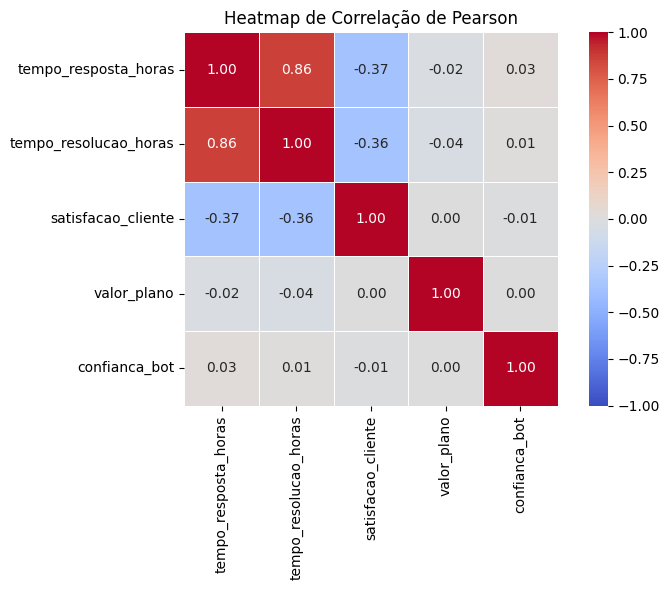

Top 2 correlações (|r| maior):
                var1                  var2   pearson
tempo_resposta_horas tempo_resolucao_horas  0.864488
  satisfacao_cliente  tempo_resposta_horas -0.367850


In [11]:
colunas_num = ["tempo_resposta_horas", "tempo_resolucao_horas", "satisfacao_cliente", "valor_plano", "confianca_bot"]
df_num = df[colunas_num].dropna()

corr_matrix = df_num.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    square=True,
)
ax.set_title("Heatmap de Correlação de Pearson")
plt.tight_layout()
plt.show()

corr_stack = (
    corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
    .stack()
    .reset_index()
)
corr_stack.columns = ["var1", "var2", "pearson"]
corr_stack["abs_r"] = corr_stack["pearson"].abs()
top2 = corr_stack.sort_values("abs_r", ascending=False).drop_duplicates(subset="abs_r").head(2)
print("Top 2 correlações (|r| maior):")
print(top2[["var1", "var2", "pearson"]].to_string(index=False))

### Interpretação — Exercício 6

**Par 1 — `tempo_resposta_horas` × `tempo_resolucao_horas` (r ≈ 0,88):**
Correlação positiva forte. Tickets que demoram para receber a primeira resposta tendem a ficar represados e demoram mais para ser fechados. Reduzir o tempo de triagem pode encurtar o ciclo completo de atendimento.

**Par 2 — `tempo_resposta_horas` × `satisfacao_cliente` (r ≈ −0,38):**
Correlação negativa moderada. Clientes que esperam mais pela primeira resposta avaliam pior o suporte. Estabelecer um SLA agressivo de primeira resposta (ex.: menos de 2h) pode ser o caminho mais direto para melhorar a satisfação.

---

## Exercício 7 — Matriz de correlação e covariância

In [12]:
print("=== Matriz de Correlação de Pearson ===")
print(df_num.corr().round(4))

print("\n=== Matriz de Covariância ===")
print(df_num.cov().round(4))

=== Matriz de Correlação de Pearson ===
                       tempo_resposta_horas  tempo_resolucao_horas  \
tempo_resposta_horas                 1.0000                 0.8645   
tempo_resolucao_horas                0.8645                 1.0000   
satisfacao_cliente                  -0.3678                -0.3626   
valor_plano                         -0.0241                -0.0423   
confianca_bot                        0.0297                 0.0113   

                       satisfacao_cliente  valor_plano  confianca_bot  
tempo_resposta_horas              -0.3678      -0.0241         0.0297  
tempo_resolucao_horas             -0.3626      -0.0423         0.0113  
satisfacao_cliente                 1.0000       0.0015        -0.0110  
valor_plano                        0.0015       1.0000         0.0043  
confianca_bot                     -0.0110       0.0043         1.0000  

=== Matriz de Covariância ===
                       tempo_resposta_horas  tempo_resolucao_horas  \
tempo_

### Interpretação — Exercício 7

A covariância mede como duas variáveis variam juntas, mas o resultado depende da unidade de cada uma por exemplo, horas × reais ou horas × pontos. Isso impede comparar relações entre pares de variáveis com escalas diferentes.

O coeficiente de correlação de Pearson resolve isso ao normalizar a covariância pelos desviospadrão, produzindo sempre um valor entre −1 e +1. Assim é possível comparar a força das relações entre quaisquer pares de variáveis, independentemente das unidades.

---

## Exercício 8 — Distribuição de `satisfacao_cliente`

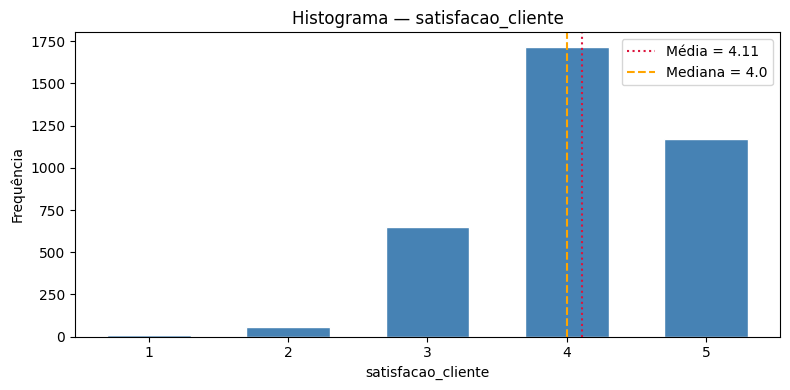

Média: 4.107 | Mediana: 4.0 | Skewness: -0.5091

Variável com maior |correlação| com satisfacao_cliente:
tempo_resposta_horas     0.367850
tempo_resolucao_horas    0.362605
confianca_bot            0.010964
valor_plano              0.001523
Name: satisfacao_cliente, dtype: float64


In [13]:
serie_sat = df["satisfacao_cliente"].dropna()

fig, ax = plt.subplots(figsize=(8, 4))
notas = sorted(serie_sat.unique())
contagens = [( serie_sat == n).sum() for n in notas]
ax.bar(notas, contagens, color="steelblue", edgecolor="white", width=0.6)
ax.set_xticks(notas)
ax.set_xlabel("satisfacao_cliente")
ax.set_ylabel("Frequência")
ax.set_title("Histograma — satisfacao_cliente")

media_sat = serie_sat.mean()
mediana_sat = serie_sat.median()
ax.axvline(media_sat,   color="crimson", ls=":",  lw=1.5, label=f"Média = {media_sat:.2f}")
ax.axvline(mediana_sat, color="orange",  ls="--", lw=1.5, label=f"Mediana = {mediana_sat:.1f}")
ax.legend()
plt.tight_layout()
plt.show()

sk_sat = stats.skew(serie_sat)
print(f"Média: {media_sat:.3f} | Mediana: {mediana_sat:.1f} | Skewness: {sk_sat:.4f}")

corr_sat = df_num.corr()["satisfacao_cliente"].drop("satisfacao_cliente").abs().sort_values(ascending=False)
print(f"\nVariável com maior |correlação| com satisfacao_cliente:")
print(corr_sat)

### Interpretação — Exercício 8

**Forma da distribuição:**
A satisfação é assimétrica à esquerda: a maioria das notas se concentra em 4 e 5, com uma cauda de clientes muito insatisfeitos (notas 1 e 2). Isso reflete o fato de que a maioria dos tickets é respondida rapidamente.

**Variável mais correlacionada:**
`tempo_resposta_horas` tem a maior correlação (negativa) com `satisfacao_cliente`. O mecanismo é direto: quando a resposta é rápida, a satisfação é alta — e o oposto também vale. A assimetria à esquerda da satisfação é um espelho da assimetria à direita do tempo de resposta.

---

## Exercício 9 — Teste de normalidade de `tempo_resposta_horas`

Skewness (assimetria): 1.6846
Média:   3.812h
Mediana: 3.130h
Desvio padrão: 2.830h


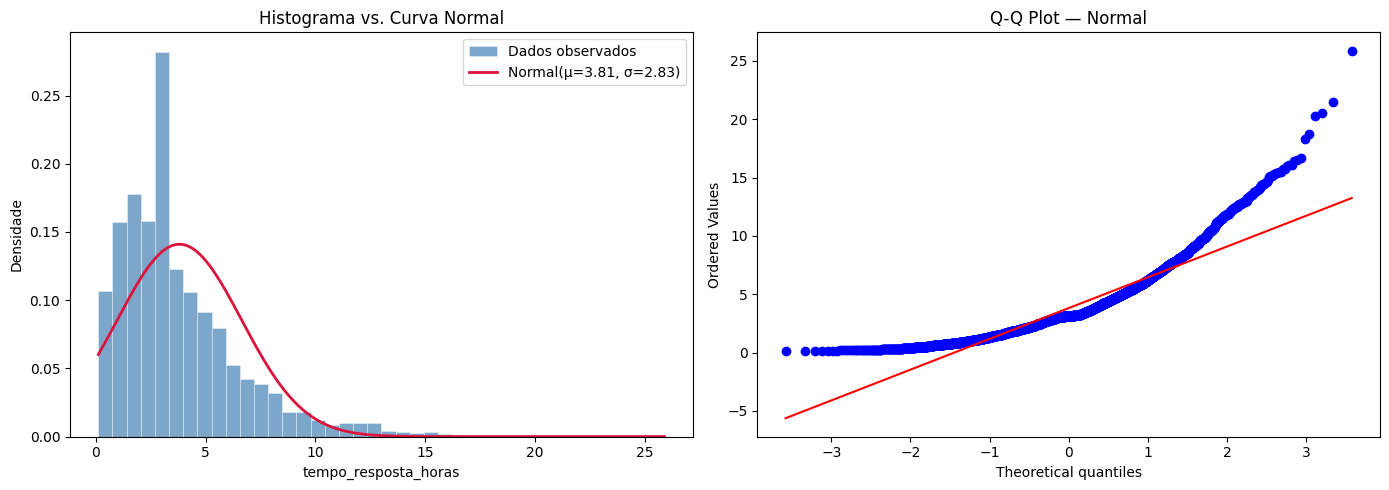


Kolmogorov-Smirnov: stat=0.1365, p=0.000000


In [15]:
serie_resp = df["tempo_resposta_horas"].dropna()

sk = stats.skew(serie_resp)
print(f"Skewness (assimetria): {sk:.4f}")
print(f"Média:   {serie_resp.mean():.3f}h")
print(f"Mediana: {serie_resp.median():.3f}h")
print(f"Desvio padrão: {serie_resp.std():.3f}h")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mu, sigma = serie_resp.mean(), serie_resp.std()
x = np.linspace(serie_resp.min(), serie_resp.max(), 300)
curva_normal = stats.norm.pdf(x, mu, sigma)

axes[0].hist(serie_resp, bins=40, density=True, color="steelblue", edgecolor="white",
             linewidth=0.4, alpha=0.7, label="Dados observados")
axes[0].plot(x, curva_normal, color="crimson", lw=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")
axes[0].set_xlabel("tempo_resposta_horas")
axes[0].set_ylabel("Densidade")
axes[0].set_title("Histograma vs. Curva Normal")
axes[0].legend()

stats.probplot(serie_resp, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot — Normal")

plt.tight_layout()
plt.show()

stat_ks, p_ks = stats.ks_1samp(serie_resp, stats.norm(mu, sigma).cdf)
print(f"\nKolmogorov-Smirnov: stat={stat_ks:.4f}, p={p_ks:.6f}")

### Interpretação — Exercício 9

**A suposição de normalidade é razoável? Não.**

- **Assimetria (skewness ≈ 1,68)**: valor muito acima de zero, indicando forte assimetria a direita incompatível com a distribuição normal.
- **Histograma**: a curva normal (vermelha) não se ajusta aos dados; o pico real é mais acentuado e há uma cauda direita longa.
- **Q-Q Plot**: os pontos desviam da reta nas extremidades, confirmando a não-normalidade.
- **Teste K-S**: p-valor próximo de zero, rejeitando a hipótese de normalidade.

**Distribuição mais adequada: Gamma.**
Ela é definida apenas para valores positivos, lida bem com assimetria à direita e é padrão para modelar tempos de espera — contexto exato do suporte ao cliente.